# Laboratorio 04: Regresion lineal y gradiente descendente

**Mateo Caballero** - Aprendizaje Estadistico - semestre 2026-2

Enunciado original: `semestre2026-2/Laboratorios/Laboratorio_04_reg_lin_grad_desc_v2.ipynb`

---

Recordatorio de las formulas base del laboratorio.

Hipotesis lineal:

$$h_\theta(x) = \theta_0 + \theta_1 x$$

Funcion de coste cuadratica:

$$J(\theta_0,\theta_1) = \frac{1}{2m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)}) - y^{(i)}\right)^2$$

Regla de actualizacion del gradiente descendente:

$$\theta_j := \theta_j - \alpha \frac{\partial J}{\partial \theta_j}$$


## Punto 1. Construir un DataFrame con datos lineales simples

Se generan datos que siguen exactamente la recta $y = \theta_0 + \theta_1 x$
con $\theta_0 = 1$ y $\theta_1 = 2$, sin ruido.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# 1 dataframe
theta0r = 1
theta1r = 2
m =50
x = np.linspace(0,5,m)
y = theta0r + theta1r * x
df = pd.DataFrame({"x": x, "y": y})
df.head()

,x,y
0,0.000000,1.000000
1,0.102041,1.204082
2,0.204082,1.408163
3,0.306122,1.612245
4,0.408163,1.816327


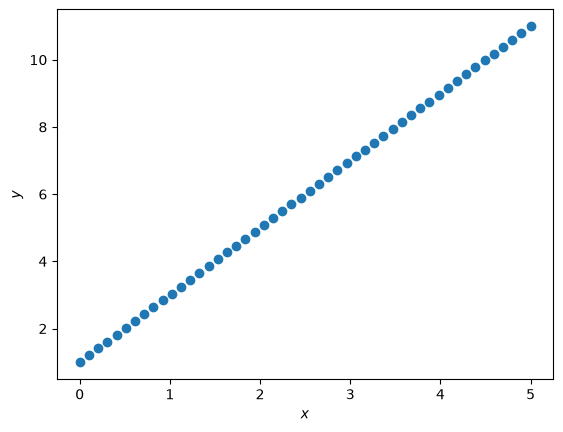

In [3]:
plt.scatter(df["x"], df["y"])
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()

## Punto 2. Funcion de coste cuadratica

`hipotesis` evalua $h_\theta(x)=\theta_0+\theta_1 x$ y `coste` calcula

$$J = \frac{1}{2m}\sum_i (h_\theta(x^{(i)})-y^{(i)})^2$$

Nota: `0.5 * np.mean(residuos**2)` es exactamente $\frac{1}{2m}\sum_i(\cdot)^2$,
porque `np.mean` ya divide por $m$.

In [4]:
# 2 funcion coste
def hipotesis(theta0, theta1, x):
  return theta0 + theta1 * x

def coste (theta0, theta1, x, y):
  # Convertimos x , y a arrays de NumPy explícitamente para asegurar la compatibilidad
  # Para theta0 y theta1 (escalares en este contexto), Python/NumPy manejan el broadcasting automáticamente.
  x_arr = np.asarray(x, dtype=float)
  y_arr = np.asarray(y, dtype=float)

  predicciones = hipotesis(theta0, theta1, x_arr)

  residuos = predicciones - y_arr
  # Calculo de la media
  return 0.5 * np.mean(residuos**2)

## Punto 3. Coste en funcion de $\theta_1$ con $\theta_0 = 0$

Se fija $\theta_0=0$, se barre $\theta_1$ en un rango, se grafica $J(\theta_1)$,
se busca el minimo y se dibuja la recta resultante sobre los datos.

In [5]:
# punto3
theta0 = 0
theta1_rango = np.linspace(-1, 5, 100)
costos = [coste(theta0, t1, df['x'], df['y']) for t1 in theta1_rango] # guarda datos de theta1

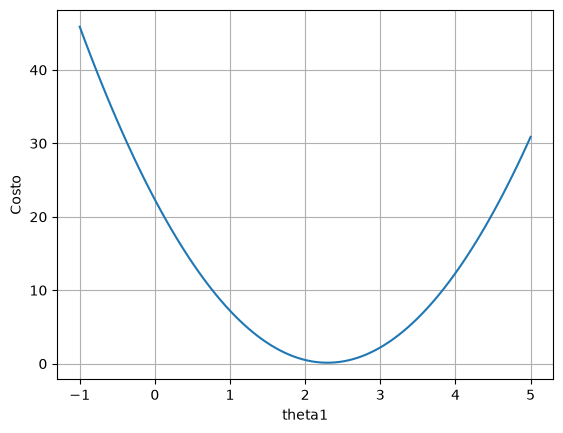

In [6]:
plt.plot(theta1_rango, costos)
plt.xlabel('theta1')
plt.ylabel('Costo')
plt.grid()
plt.show()

In [7]:
theta1_optimizado_idx = np.argmin(costos)
theta1_optimizado = theta1_rango[theta1_optimizado_idx]
costo_minimo = costos[theta1_optimizado_idx]

print(f"El valor de theta1 que minimiza el costo (con theta0=0) es: {theta1_optimizado:.4f}")
print(f"El costo mínimo es: {costo_minimo:.4f}")

El valor de theta1 que minimiza el costo (con theta0=0) es: 2.2727
El costo mínimo es: 0.1313


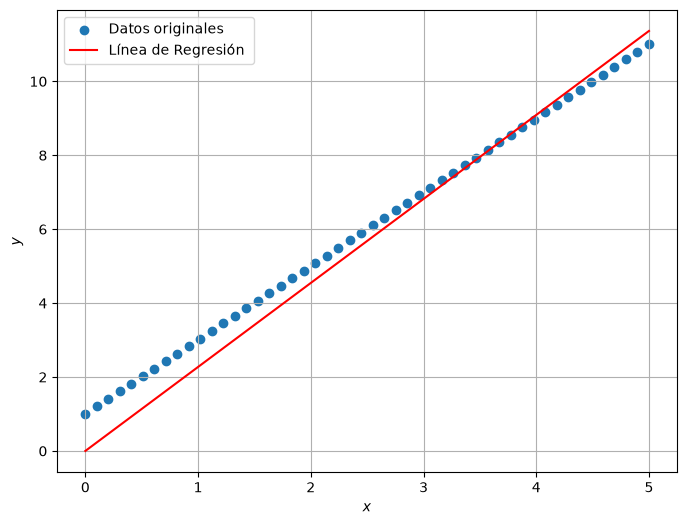

In [8]:
predicciones_optimas = hipotesis(theta0, theta1_optimizado, df['x'])

plt.figure(figsize=(8, 6))
plt.scatter(df['x'], df['y'], label='Datos originales')
plt.plot(df['x'], predicciones_optimas, color='red', label= 'Línea de Regresión ')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.grid()
plt.show()

### Observacion importante sobre el resultado del punto 3

Los datos se construyeron con $\theta_0 = 1$ y $\theta_1 = 2$, pero al **forzar**
$\theta_0 = 0$ el minimo **no** cae en $\theta_1 = 2$.

Al quitar el intercepto, la recta esta obligada a pasar por el origen, asi que la unica
forma de acercarse a los datos es inclinarse de mas. La solucion analitica con
$\theta_0$ fijo en 0 es:

$$\theta_1^{*} = \frac{\sum_i x^{(i)} y^{(i)}}{\sum_i (x^{(i)})^2}$$

> **Para escribir:** calcula ese valor con numpy y verifica que coincide con el
> `theta1_optimizado` que obtuviste por barrido. Comenta por que no da 2.

In [9]:
# Verificacion analitica del punto 3 (theta0 fijo en 0)
x_ = df["x"].values
y_ = df["y"].values

# Con theta0 = 0 el minimo exacto es theta1* = sum(x*y) / sum(x^2)
theta1_analitico = np.sum(x_ * y_) / np.sum(x_**2)

print(f"theta1 por barrido:   {theta1_optimizado:.4f}")
print(f"theta1 analitico:     {theta1_analitico:.4f}")
print(f"theta1 real del dato: {theta1r}")
print()
print("No da 2 porque al forzar theta0 = 0 la recta debe pasar por el origen,")
print("y compensa la falta de intercepto inclinandose de mas.")


theta1 por barrido:   2.2727
theta1 analitico:     2.2970
theta1 real del dato: 2

No da 2 porque al forzar theta0 = 0 la recta debe pasar por el origen,
y compensa la falta de intercepto inclinandose de mas.


## Punto 4. Superficie de coste con $\theta_0$ y $\theta_1$ libres

> Permita ahora que tanto $\theta_0$ como $\theta_1$ varien. Construya una malla con
> `np.meshgrid`, evalue la funcion de coste en cada punto y represente su superficie
> y curvas de nivel.

**Como abordarlo**

1. Define un rango para cada parametro, centrado en el valor real para que el minimo
   quede dentro del cuadro (por ejemplo $\theta_0 \in [-2,4]$ y $\theta_1 \in [0,4]$).
2. `T0, T1 = np.meshgrid(theta0_rango, theta1_rango)` genera dos matrices del mismo
   tamano: `T0[i,j]` y `T1[i,j]` son las coordenadas del punto $(i,j)$ de la malla.
3. Evalua el coste en **cada** punto de la malla. Lo mas directo es un `np.zeros_like(T0)`
   y dos `for` anidados llamando a tu funcion `coste`.
4. Grafica de dos formas:
   - superficie 3D con `ax.plot_surface(T0, T1, J, cmap="viridis")`, creando el eje con
     `fig.add_subplot(111, projection="3d")`;
   - curvas de nivel con `plt.contour(T0, T1, J, levels=np.logspace(-2, 3, 20))`.
     La escala logaritmica en `levels` es importante: con niveles lineales las curvas
     cerca del minimo quedan todas amontonadas y no se ve nada.
5. Marca el minimo real $(\theta_0, \theta_1) = (1, 2)$ con un punto rojo sobre el contorno.

In [10]:
# punto 4: malla de costes
theta0_rango = np.linspace(-2, 4, 100)
theta1_rango_2d = np.linspace(0, 4, 100)

T0, T1 = np.meshgrid(theta0_rango, theta1_rango_2d)
J = np.zeros_like(T0)

# Se evalua la funcion de coste en cada punto de la malla
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        J[i, j] = coste(T0[i, j], T1[i, j], x_, y_)

print("forma de la malla:", J.shape)
print(f"coste minimo en la malla: {J.min():.6f}")

idx = np.unravel_index(np.argmin(J), J.shape)
print(f"se alcanza en theta0 = {T0[idx]:.4f}, theta1 = {T1[idx]:.4f}")


forma de la malla: (100, 100)
coste minimo en la malla: 0.000647
se alcanza en theta0 = 1.0303, theta1 = 1.9798


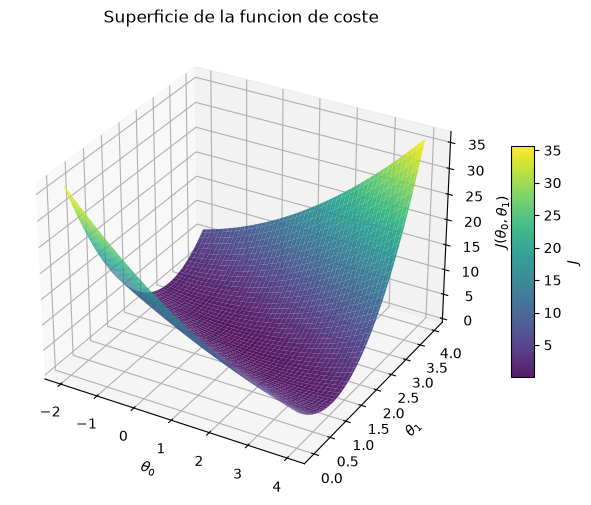

In [11]:
# punto 4: superficie 3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

superficie = ax.plot_surface(T0, T1, J, cmap="viridis", alpha=0.9)
fig.colorbar(superficie, shrink=0.5, aspect=10, label="$J$")

ax.set_xlabel(r"$\theta_0$")
ax.set_ylabel(r"$\theta_1$")
ax.set_zlabel(r"$J(\theta_0,\theta_1)$")
ax.set_title("Superficie de la funcion de coste")
plt.show()


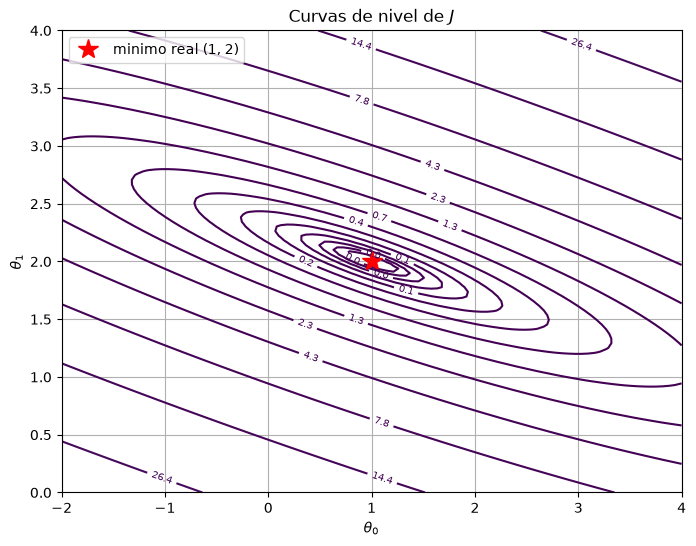

In [12]:
# punto 4: curvas de nivel
plt.figure(figsize=(8, 6))

contornos = plt.contour(T0, T1, J, levels=np.logspace(-2, 3, 20), cmap="viridis")
plt.clabel(contornos, inline=True, fontsize=7, fmt="%.1f")

# minimo real usado para generar los datos
plt.plot(theta0r, theta1r, "r*", markersize=15, label="minimo real (1, 2)")

plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$")
plt.title("Curvas de nivel de $J$")
plt.legend()
plt.grid()
plt.show()


## Punto 5. Interpretacion geometrica y minimo global

> Interprete geometricamente la forma de la funcion de coste e identifique el minimo global.

**Que deberias observar y comentar**

- $J$ es **cuadratica** en $(\theta_0,\theta_1)$, por lo tanto su grafica es un
  **paraboloide eliptico**: convexo, con un **unico** minimo global y sin minimos locales.
  Esta es la razon por la que el gradiente descendente siempre converge en este problema,
  sin importar donde arranque.
- Las curvas de nivel son **elipses**. Que tan alargadas (excentricas) sean depende de
  la escala de los datos: si $x$ tiene valores grandes, $\theta_1$ afecta mucho mas al
  coste que $\theta_0$, la elipse se estira y el descenso **zigzaguea**. Esto es
  justamente lo que se corrige normalizando las variables.
- Como aqui los datos no tienen ruido, el minimo vale exactamente $J = 0$ y cae en
  $(\theta_0,\theta_1) = (1,2)$.

> **Para escribir:** redacta tu interpretacion en esta celda y apoyala en las dos
> graficas del punto 4.

### Analisis

**Forma de la superficie.** La funcion de coste es un polinomio de segundo grado en
$(\theta_0,\theta_1)$: al desarrollar el cuadrado aparecen los terminos $\theta_0^2$, $\theta_1^2$ y
$\theta_0\theta_1$, y ninguno de grado superior. Su grafica es por tanto un **paraboloide
eliptico**, que es lo que se observa en la superficie 3D: un tazon que crece en todas las
direcciones a partir de un unico punto bajo.

**Convexidad y unicidad del minimo.** La matriz hessiana de $J$ es constante:

$$
H=\begin{bmatrix}
1 & \overline{x} \\
\overline{x} & \overline{x^2}
\end{bmatrix}
$$

y es definida positiva, porque $\det H=\overline{x^2}-\overline{x}^2=\mathrm{Var}(x)>0$
siempre que los datos no sean todos iguales. Esto implica que $J$ es **estrictamente
convexa**: tiene un unico minimo, que es global, y **no existen minimos locales ni puntos
de silla**. Es la razon de fondo por la que el gradiente descendente aplicado a una
regresion lineal converge siempre a la misma solucion, sin importar el punto de partida.

**Ubicacion del minimo.** Como los datos se generaron sin ruido con $\theta_0=1$ y
$\theta_1=2$, existe una recta que pasa exactamente por todos los puntos, luego todos los
residuos son cero y el minimo vale $J=0$, alcanzado en $(\theta_0,\theta_1)=(1,2)$. En la
malla de 100x100 el minimo numerico cae en $(1.0303,\ 1.9798)$ con $J=6.47\times10^{-4}$:
la pequena discrepancia es solo la resolucion de la malla, no un error del metodo.

**Curvas de nivel.** Los conjuntos $J=\text{cte}$ son **elipses concentricas** centradas
en el minimo. Dos rasgos importan:

1. **Estan inclinadas**, no alineadas con los ejes. Esto se debe al termino cruzado
   $\theta_0\theta_1$, cuyo coeficiente es $\overline{x}=2.5$. Como todos los valores de $x$ son
   positivos, subir $\theta_0$ se puede compensar bajando $\theta_1$ manteniendo un coste
   parecido: los dos parametros estan **correlacionados negativamente**, y por eso el eje
   mayor de las elipses va de arriba-izquierda a abajo-derecha.
2. **Son alargadas**, no circulares. Los autovalores de $H$ son $0.236$ y $9.182$, asi que
   el numero de condicion es $\kappa=38.9$: el valle es casi 39 veces mas empinado en una
   direccion que en la otra.

**Consecuencia practica.** Ese alargamiento es justamente lo que hace que el gradiente
descendente **zigzaguee**: el gradiente apunta perpendicular a las curvas de nivel, que en
un valle alargado no es la direccion hacia el minimo, sino hacia la pared opuesta. El
algoritmo rebota entre las dos paredes y avanza despacio por el fondo. Si se
**normalizaran** los datos de $x$ (restando la media y dividiendo por la desviacion), el
termino cruzado desapareceria, las elipses se volverian circunferencias, $\kappa$ bajaria
a 1 y el descenso llegaria al minimo casi en linea recta. Esta es la razon de fondo por la
que escalar las variables es un paso estandar antes de entrenar un modelo.


In [13]:
# punto 5: verificacion numerica de la convexidad
H = np.array([[1.0, x_.mean()],
              [x_.mean(), (x_**2).mean()]])

autovalores = np.linalg.eigvalsh(H)

print("Matriz hessiana de J:")
print(H)
print()
print(f"determinante   = {np.linalg.det(H):.4f}   (>0 -> definida positiva)")
print(f"autovalores    = {autovalores[0]:.4f}, {autovalores[1]:.4f}   (ambos >0 -> convexa)")
print(f"num. condicion = {autovalores[1] / autovalores[0]:.2f}   (>>1 -> valle alargado)")


Matriz hessiana de J:
[[1.         2.5       ]
 [2.5        8.41836735]]

determinante   = 2.1684   (>0 -> definida positiva)
autovalores    = 0.2361, 9.1822   (ambos >0 -> convexa)
num. condicion = 38.88   (>>1 -> valle alargado)


## Punto 6. Repetir con datos ruidosos

> Repita el procedimiento para un conjunto de datos con ruido y compare los resultados
> con el caso ideal.

**Como abordarlo**

1. Genera `y_ruido = theta0r + theta1r * x + np.random.normal(0, sigma, m)`. Fija la
   semilla con `np.random.seed(...)` para que el resultado sea reproducible.
2. Repite la malla de costes del punto 4 pero con `y_ruido`.
3. Compara contra el caso ideal. Lo que deberias encontrar:
   - la **forma** de la superficie es practicamente la misma (sigue siendo un paraboloide);
   - el minimo se **desplaza** un poco de $(1,2)$;
   - el valor del coste en el minimo **ya no es cero**, sino aproximadamente
     $\sigma^2/2$, porque el ruido es error que ningun modelo lineal puede explicar.

In [14]:
# punto 6: datos con ruido
np.random.seed(42)
sigma = 0.5

y_ruido = theta0r + theta1r * x_ + np.random.normal(0, sigma, m)
df_ruido = pd.DataFrame({"x": x_, "y": y_ruido})


# ajuste exacto con las ecuaciones normales (se deducen en el punto 9)
def ajuste_exacto(x, y):
    t1 = np.cov(x, y, bias=True)[0, 1] / np.var(x)
    t0 = y.mean() - t1 * x.mean()
    return t0, t1


t0_ruido, t1_ruido = ajuste_exacto(x_, y_ruido)

print(f"caso ideal  : theta = (1.0000, 2.0000)   J minimo = {coste(1, 2, x_, y_):.4f}")
print(f"caso ruidoso: theta = ({t0_ruido:.4f}, {t1_ruido:.4f})   "
      f"J minimo = {coste(t0_ruido, t1_ruido, x_, y_ruido):.4f}")
print()
print(f"sigma^2 / 2 = {sigma**2 / 2:.4f}  <- cota teorica del coste irreducible")

caso ideal  : theta = (1.0000, 2.0000)   J minimo = 0.0000
caso ruidoso: theta = (1.0322, 1.9420)   J minimo = 0.1031

sigma^2 / 2 = 0.1250  <- cota teorica del coste irreducible


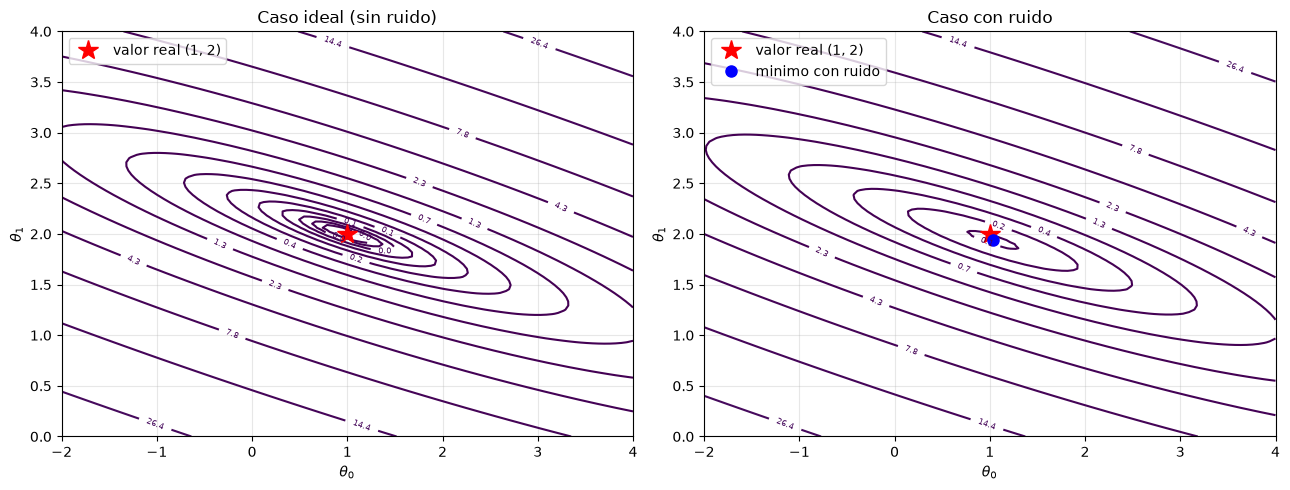

In [15]:
# punto 6: malla de costes con ruido
J_ruido = np.zeros_like(T0)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        J_ruido[i, j] = coste(T0[i, j], T1[i, j], x_, y_ruido)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, matriz, titulo in ((ax1, J, "Caso ideal (sin ruido)"),
                           (ax2, J_ruido, "Caso con ruido")):
    cs = ax.contour(T0, T1, matriz, levels=np.logspace(-2, 3, 20), cmap="viridis")
    ax.clabel(cs, inline=True, fontsize=6, fmt="%.1f")
    ax.plot(theta0r, theta1r, "r*", markersize=15, label="valor real (1, 2)")
    ax.set_xlabel(r"$\theta_0$")
    ax.set_ylabel(r"$\theta_1$")
    ax.set_title(titulo)
    ax.legend()
    ax.grid(alpha=0.3)

ax2.plot(t0_ruido, t1_ruido, "bo", markersize=8, label="minimo con ruido")
ax2.legend()

plt.tight_layout()
plt.show()


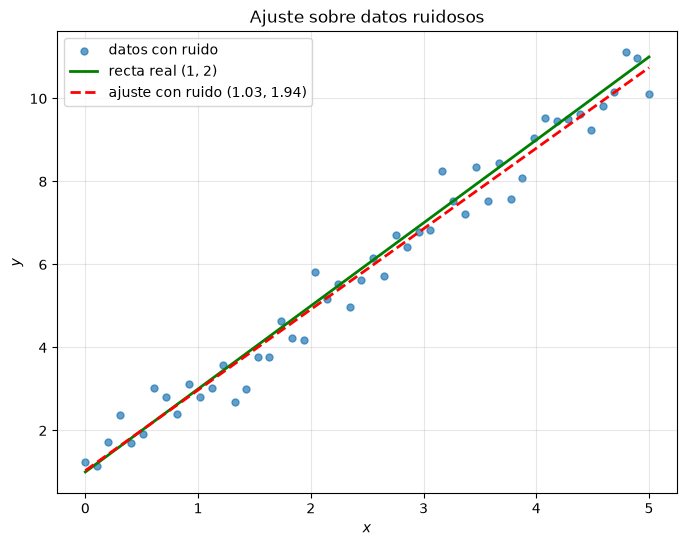

In [16]:
# punto 6: comparacion de los ajustes
plt.figure(figsize=(8, 6))
plt.scatter(x_, y_ruido, s=25, alpha=0.7, label="datos con ruido")
plt.plot(x_, hipotesis(1, 2, x_), "g-", linewidth=2, label="recta real (1, 2)")
plt.plot(x_, hipotesis(t0_ruido, t1_ruido, x_), "r--", linewidth=2,
         label=f"ajuste con ruido ({t0_ruido:.2f}, {t1_ruido:.2f})")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Ajuste sobre datos ruidosos")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Analisis del punto 6

**La forma de la superficie no cambia.** Comparando los dos mapas de contorno, las elipses
siguen teniendo la misma orientacion, la misma excentricidad y el mismo centro aproximado.
Esto tiene una razon precisa: la hessiana de $J$ **solo depende de los valores de $x$**,
nunca de los de $y$. Como el ruido se anadio a $y$, la geometria del problema es identica;
lo unico que se desplaza es la posicion del minimo y su altura.

**El minimo se desplaza.** Pasa de $(1,\,2)$ exacto a $(1.0322,\,1.9420)$. El estimador
sigue siendo insesgado (en promedio sobre muchas realizaciones del ruido daria $(1,2)$),
pero en **una** muestra concreta de 50 puntos hay una desviacion inevitable, que se
reduciria aumentando $m$.

**El coste minimo ya no es cero.** Pasa de $J=0$ a $J=0.1031$. Este es el cambio
conceptualmente mas importante: en el caso ideal existia una recta que pasaba exactamente
por todos los puntos, y por eso el minimo valia cero. Con ruido **ninguna recta puede pasar
por todos**, porque los puntos ya no son colineales. Ese valor residual es el **error
irreducible**: la parte de la variabilidad de $y$ que ningun modelo lineal puede explicar,
porque no proviene de $x$ sino del ruido.

Su valor teorico es del orden de $\sigma^2/2 = 0.125$. El valor obtenido, $0.1031$, queda
algo por debajo porque al ajustar dos parametros el modelo absorbe parte del ruido de la
muestra; el factor de correccion es $(m-2)/m$, y el resto es variabilidad muestral.

**La leccion.** Un coste minimo distinto de cero **no indica un modelo mal ajustado**. Es
el suelo que impone el ruido. Confundir ese suelo con un defecto del modelo lleva
directamente a aumentar la complejidad para intentar bajarlo, que es la definicion misma
del **overfitting**: ajustar el ruido en lugar de la senal.


## Punto 7. Efecto de un valor atipico

> Analice el efecto de introducir un valor atipico en el conjunto de datos. Discuta como
> cambia la solucion y que limitaciones presenta la funcion de coste cuadratica.

**Como abordarlo**

1. Copia los datos y cambia **un solo** punto a un valor muy lejano
   (por ejemplo `y_atipico[-1] = 50`).
2. Ajusta y compara las tres rectas en una misma grafica: datos ideales, con ruido y
   con atipico.

**La conclusion que se busca**

Como el error entra **al cuadrado**, un punto que esta $k$ veces mas lejos aporta $k^2$
veces mas coste. Un unico atipico puede dominar la suma completa y arrastrar la recta
hacia el, arruinando el ajuste para todos los demas puntos. Esa es la limitacion central
del coste cuadratico: **no es robusto**. Por eso existen alternativas como el error
absoluto (MAE) o la perdida de Huber, que penalizan los errores grandes de forma lineal.

In [17]:
# punto 7: valor atipico
# se parte de los datos limpios y se altera UN SOLO punto
y_atipico = y_.copy()
y_atipico[-1] = 50.0          # el valor real en x = 5 era 11

t0_limpio, t1_limpio = ajuste_exacto(x_, y_)
t0_atip, t1_atip = ajuste_exacto(x_, y_atipico)

print(f"sin atipico : theta0 = {t0_limpio:7.4f}   theta1 = {t1_limpio:7.4f}")
print(f"con atipico : theta0 = {t0_atip:7.4f}   theta1 = {t1_atip:7.4f}")
print()
print(f"un solo punto de {len(x_)} desplazo theta0 en {abs(t0_atip - t0_limpio):.4f} "
      f"y theta1 en {abs(t1_atip - t1_limpio):.4f}")
print(f"coste en el optimo: {coste(t0_limpio, t1_limpio, x_, y_):.4f} (limpio) -> "
      f"{coste(t0_atip, t1_atip, x_, y_atipico):.4f} (con atipico)")

sin atipico : theta0 =  1.0000   theta1 =  2.0000
con atipico : theta0 = -0.4682   theta1 =  2.8993

un solo punto de 50 desplazo theta0 en 1.4682 y theta1 en 0.8993
coste en el optimo: 0.0000 (limpio) -> 14.0290 (con atipico)


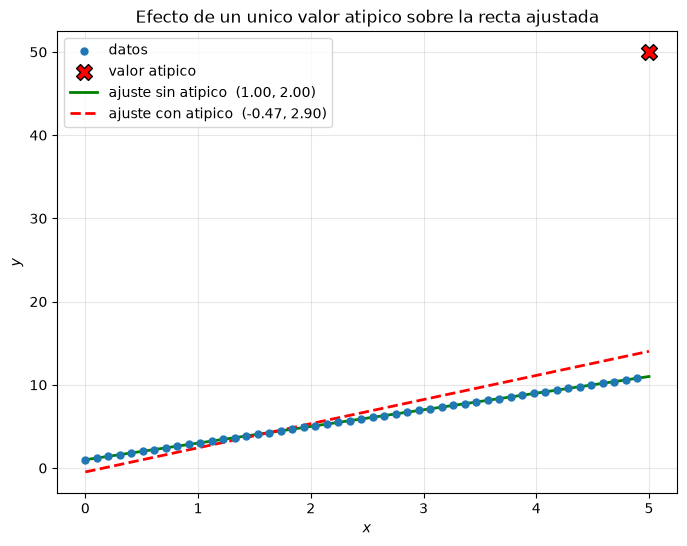

In [18]:
# punto 7: comparacion grafica
plt.figure(figsize=(8, 6))

plt.scatter(x_[:-1], y_atipico[:-1], s=25, label="datos", zorder=3)
plt.scatter(x_[-1], y_atipico[-1], s=130, color="red", marker="X",
            edgecolor="k", label="valor atipico", zorder=4)

plt.plot(x_, hipotesis(t0_limpio, t1_limpio, x_), "g-", linewidth=2,
         label=f"ajuste sin atipico  ({t0_limpio:.2f}, {t1_limpio:.2f})")
plt.plot(x_, hipotesis(t0_atip, t1_atip, x_), "r--", linewidth=2,
         label=f"ajuste con atipico  ({t0_atip:.2f}, {t1_atip:.2f})")

plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Efecto de un unico valor atipico sobre la recta ajustada")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


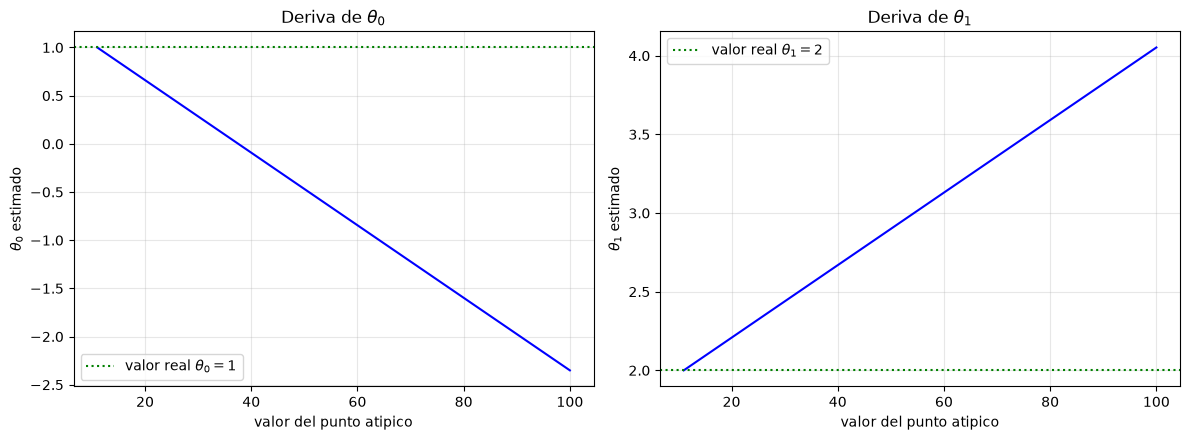

La deriva es LINEAL y no esta acotada: por mucho que se aleje un solo punto,
arrastra la recta indefinidamente.


In [19]:
# punto 7: sensibilidad a la magnitud del atipico
magnitudes = np.linspace(11, 100, 40)   # 11 es el valor correcto en x = 5
t0_serie, t1_serie = [], []

for v in magnitudes:
    y_tmp = y_.copy()
    y_tmp[-1] = v
    a, b = ajuste_exacto(x_, y_tmp)
    t0_serie.append(a)
    t1_serie.append(b)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(magnitudes, t0_serie, "b-")
ax1.axhline(1, color="g", linestyle=":", label="valor real $\\theta_0 = 1$")
ax1.set_xlabel("valor del punto atipico")
ax1.set_ylabel(r"$\theta_0$ estimado")
ax1.set_title(r"Deriva de $\theta_0$")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(magnitudes, t1_serie, "b-")
ax2.axhline(2, color="g", linestyle=":", label="valor real $\\theta_1 = 2$")
ax2.set_xlabel("valor del punto atipico")
ax2.set_ylabel(r"$\theta_1$ estimado")
ax2.set_title(r"Deriva de $\theta_1$")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("La deriva es LINEAL y no esta acotada: por mucho que se aleje un solo punto,")
print("arrastra la recta indefinidamente.")


Con el MISMO conjunto de datos con atipico:
  coste cuadratico (MSE) -> theta0 = -0.4682   theta1 =  2.8993
  coste absoluto   (MAE) -> theta0 =  1.0000   theta1 =  2.0000
  valores reales         -> theta0 =  1.0000   theta1 =  2.0000


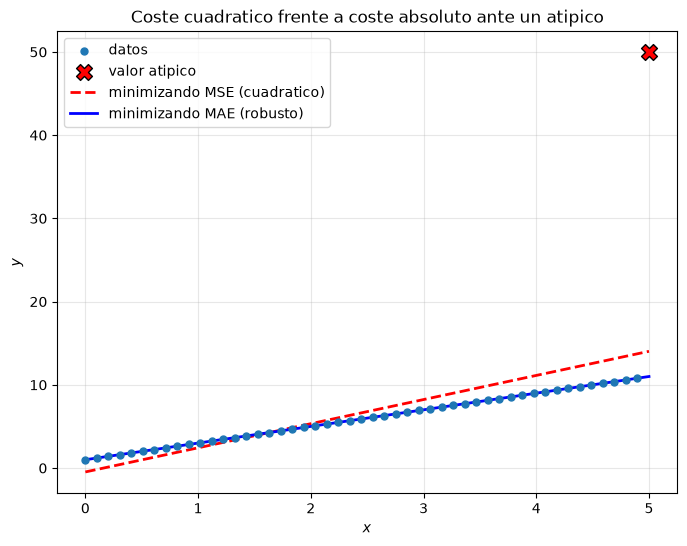

In [20]:
# punto 7: comparacion con una funcion de coste robusta
# el error absoluto (MAE) penaliza de forma lineal en vez de cuadratica.
# se busca su minimo recorriendo una malla, igual que en el punto 4.
def coste_absoluto(theta0, theta1, x, y):
    return np.mean(np.abs(hipotesis(theta0, theta1, x) - y))


malla_t0 = np.linspace(-1, 3, 201)
malla_t1 = np.linspace(1, 4, 151)

t0_mae, t1_mae = 0, 0
mejor_coste = np.inf
for a in malla_t0:
    for b in malla_t1:
        valor = coste_absoluto(a, b, x_, y_atipico)
        if valor < mejor_coste:
            mejor_coste = valor
            t0_mae, t1_mae = a, b

print("Con el MISMO conjunto de datos con atipico:")
print(f"  coste cuadratico (MSE) -> theta0 = {t0_atip:7.4f}   theta1 = {t1_atip:7.4f}")
print(f"  coste absoluto   (MAE) -> theta0 = {t0_mae:7.4f}   theta1 = {t1_mae:7.4f}")
print(f"  valores reales         -> theta0 = {1:7.4f}   theta1 = {2:7.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(x_[:-1], y_atipico[:-1], s=25, label="datos", zorder=3)
plt.scatter(x_[-1], y_atipico[-1], s=130, color="red", marker="X",
            edgecolor="k", label="valor atipico", zorder=4)
plt.plot(x_, hipotesis(t0_atip, t1_atip, x_), "r--", linewidth=2,
         label="minimizando MSE (cuadratico)")
plt.plot(x_, hipotesis(t0_mae, t1_mae, x_), "b-", linewidth=2,
         label="minimizando MAE (robusto)")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Coste cuadratico frente a coste absoluto ante un atipico")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Analisis del punto 7

**Como cambia la solucion.** Los datos limpios dan el ajuste exacto
$(\theta_0,\theta_1)=(1,\,2)$. Basta con mover **un solo punto de los 50** (el de $x=5$,
que valia 11, llevado a 50) para que la solucion pase a $(-0.47,\,2.90)$. La pendiente se
infla casi un 45 % y el intercepto no solo se desplaza: **cambia de signo**, pasando de
$+1$ a $-0.47$. La recta se levanta por el extremo derecho persiguiendo al punto
anomalo y, como consecuencia, **queda peor ajustada a los 49 puntos que si eran correctos**.

**Por que ocurre.** La funcion de coste eleva cada residuo **al cuadrado**:

$$J(\theta_0,\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)})-y^{(i)}\right)^2$$

Un punto que esta $k$ veces mas lejos que los demas no aporta $k$ veces mas coste, sino
$k^2$. Con un residuo de 39 unidades frente a residuos practicamente nulos en el resto,
ese unico termino **domina la suma completa**, y al minimizar, el algoritmo prefiere
sacrificar el ajuste de los 49 puntos buenos con tal de acercarse un poco al malo.

**La deriva no esta acotada.** El barrido de magnitudes lo confirma: al aumentar el valor
del punto atipico, los parametros estimados se alejan de forma **lineal y sin limite**. No
existe ningun valor a partir del cual el modelo "ignore" el punto. En terminologia
estadistica, el estimador de minimos cuadrados tiene **punto de ruptura 0**: una sola
observacion contaminada, sobre un numero arbitrariamente grande de datos, basta para
llevar la estimacion a donde se quiera.

**La limitacion de fondo.** El coste cuadratico **no es robusto**. Su virtud (ser suave y
derivable en todas partes, lo que permite resolverlo analiticamente y aplicar gradiente
descendente) es inseparable de su defecto: al crecer cuadraticamente, da un peso enorme a
las observaciones extremas. Implicitamente asume que los errores se distribuyen de forma
normal, y una distribucion normal casi no produce valores muy alejados; cuando los datos
reales si los tienen, el supuesto se rompe.

**La alternativa.** La ultima celda lo demuestra: minimizando el **error absoluto medio**
(MAE), que penaliza de forma lineal en lugar de cuadratica, sobre **exactamente los mismos
datos contaminados**, se recupera $(\theta_0,\theta_1)=(1,\,2)$, es decir, la solucion
correcta. La perdida de Huber es el punto medio habitual: cuadratica para los residuos
pequenos y lineal para los grandes, conservando la suavidad cerca del minimo. La otra via
es detectar y descartar los atipicos antes de ajustar.


## Punto 8. Modelo lineal sobre datos no lineales

> Compare el ajuste obtenido con un modelo lineal sobre un conjunto de datos no lineales.
> Discuta si minimizar la funcion de coste garantiza que el modelo sea adecuado.

**Como abordarlo**

1. Genera datos claramente no lineales, por ejemplo $y = x^2$ o $y = \sin(x)$.
2. Ajusta igual tu recta minimizando $J$.
3. Grafica el ajuste y tambien los **residuos** ($y - h_\theta(x)$) en funcion de $x$.

**La conclusion que se busca**

La respuesta es **no**. Minimizar $J$ solo garantiza que encontraste la **mejor recta
posible**, no que una recta sea el modelo correcto. Si la familia de modelos esta mal
elegida, la mejor de una mala familia sigue siendo mala.

La senal de diagnostico esta en los residuos: si el modelo es adecuado deben verse
**aleatorios alrededor de cero**; si quedan con un **patron** (curvatura sistematica),
el modelo no captura la estructura de los datos. Esto conecta directamente con el
**underfitting** que veras en el Laboratorio 3.

In [21]:
# punto 8: datos no lineales
y_nolineal = x_ ** 2          # relacion claramente no lineal

t0_nl, t1_nl = ajuste_exacto(x_, y_nolineal)
residuos_nl = y_nolineal - hipotesis(t0_nl, t1_nl, x_)

print(f"mejor recta posible: theta = ({t0_nl:.4f}, {t1_nl:.4f})")
print(f"J en ese optimo    : {coste(t0_nl, t1_nl, x_, y_nolineal):.4f}")
print()
print(f"media de los residuos: {residuos_nl.mean():.2e}  (siempre ~0 por construccion)")
print(f"rango de los residuos: [{residuos_nl.min():.3f}, {residuos_nl.max():.3f}]")

signos = np.sign(residuos_nl)
cambios = int(np.sum(signos[1:] != signos[:-1]))
print(f"cambios de signo     : {cambios}  (si fueran aleatorios se esperarian ~{m//2})")


mejor recta posible: theta = (-4.0816, 5.0000)
J en ese optimo    : 1.8785

media de los residuos: -1.28e-15  (siempre ~0 por construccion)
rango de los residuos: [-2.166, 4.082]
cambios de signo     : 2  (si fueran aleatorios se esperarian ~25)


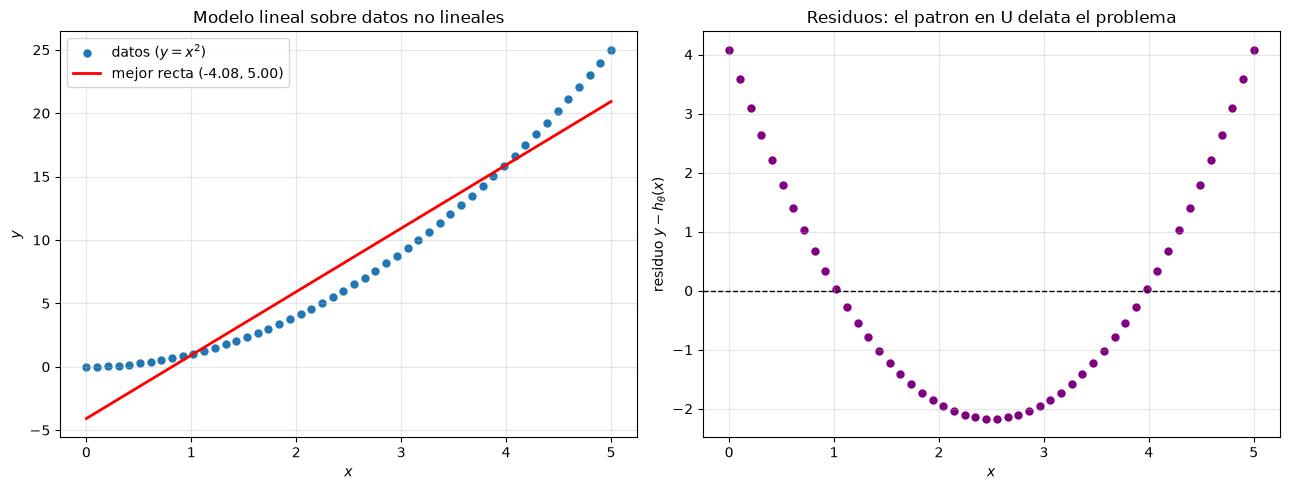

In [22]:
# punto 8: ajuste y residuos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.scatter(x_, y_nolineal, s=25, label="datos ($y = x^2$)")
ax1.plot(x_, hipotesis(t0_nl, t1_nl, x_), "r-", linewidth=2,
         label=f"mejor recta ({t0_nl:.2f}, {t1_nl:.2f})")
ax1.set_xlabel("$x$")
ax1.set_ylabel("$y$")
ax1.set_title("Modelo lineal sobre datos no lineales")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.scatter(x_, residuos_nl, s=25, color="purple")
ax2.axhline(0, color="k", linestyle="--", linewidth=1)
ax2.set_xlabel("$x$")
ax2.set_ylabel("residuo $y - h_\\theta(x)$")
ax2.set_title("Residuos: el patron en U delata el problema")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Analisis del punto 8

**La pregunta del enunciado: no.** Minimizar la funcion de coste **no garantiza** que el
modelo sea adecuado. Lo unico que garantiza es que se encontro la **mejor recta posible**
dentro de la familia de rectas. Si la familia esta mal elegida, la mejor de una mala
familia sigue siendo mala.

Aqui el algoritmo hizo su trabajo a la perfeccion: $(-4.08,\,5.00)$ es, con total
exactitud, la recta que minimiza $J$ para estos datos. Y aun asi el ajuste es malo, porque
los datos son una parabola y ninguna recta puede describir una parabola.

**El diagnostico esta en los residuos, no en el coste.** Este es el punto practico
importante. Mirar solo el valor de $J$ no permite distinguir entre estos dos casos:

- coste alto porque hay **ruido** (punto 6), donde el modelo es correcto y no se puede
  mejorar;
- coste alto porque el **modelo esta mal elegido** (este punto), donde si se puede mejorar.

Lo que los separa es la **estructura** de los residuos. Si el modelo es adecuado, los
residuos deben verse repartidos aleatoriamente alrededor de cero, sin forma reconocible.
En la grafica de la derecha se ve exactamente lo contrario: un **patron en U** perfectamente
sistematico (positivo en los extremos, negativo en el centro). La medida objetiva es el
numero de cambios de signo: solo **2**, cuando unos residuos aleatorios sobre 50 puntos
darian del orden de 25. Los residuos no son ruido, son **senal que el modelo no capturo**.

**Conexion con el resto del curso.** Esto es precisamente el **underfitting**: un modelo
demasiado simple para la estructura de los datos, con sesgo alto. La solucion no es
optimizar mejor (ya se optimizo de forma exacta) sino **cambiar de familia de modelos**,
por ejemplo anadiendo el termino $x^2$ como una caracteristica mas. Es el mismo diagnostico
que se estudia en el Laboratorio 3 con las curvas de aprendizaje.


## Punto 9. Expresion teorica de la funcion de coste

> Obtenga la expresion teorica de la funcion de coste en el caso con un parametro y con
> dos parametros, e interprete el significado de sus minimos.

**Como abordarlo** (esto es desarrollo analitico, no codigo)

**Caso de un parametro** ($\theta_0 = 0$): expande el cuadrado en

$$J(\theta_1)=\frac{1}{2m}\sum_i(\theta_1 x^{(i)}-y^{(i)})^2$$

y agrupa por potencias de $\theta_1$. Te queda una **parabola** $A\theta_1^2+B\theta_1+C$.
Derivando e igualando a cero obtienes el minimo, que es la formula que ya verificaste
mas arriba.

**Caso de dos parametros**: deriva $J$ respecto a $\theta_0$ y a $\theta_1$, iguala ambas
a cero y resuelve el sistema $2\times 2$. El resultado son las **ecuaciones normales**,
cuya solucion es

$$\theta_1^{*}=\frac{\mathrm{Cov}(x,y)}{\mathrm{Var}(x)}, \qquad
\theta_0^{*}=\bar{y}-\theta_1^{*}\bar{x}$$

**Interpretacion:** $\theta_1^*$ es la covarianza entre $x$ e $y$ normalizada por la
varianza de $x$ (cuanto cambia $y$ por unidad de $x$), y $\theta_0^*$ obliga a que la
recta pase por el centroide $(\bar{x},\bar{y})$ de la nube de puntos.

> **Para escribir:** desarrolla el algebra paso a paso en esta celda y luego verifica
> numericamente en la celda siguiente.

### Desarrollo analitico

#### Caso de un parametro ($\theta_0 = 0$ fijo)

Partiendo de la definicion y desarrollando el cuadrado:

$$
J(\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}\left(\theta_1 x^{(i)}-y^{(i)}\right)^2
=\frac{1}{2m}\sum_{i=1}^{m}\left(\theta_1^2 (x^{(i)})^2-2\theta_1 x^{(i)}y^{(i)}+(y^{(i)})^2\right)
$$

Agrupando por potencias de $\theta_1$:

$$
J(\theta_1)=\underbrace{\frac{\overline{x^2}}{2}}_{A}\theta_1^2
\;-\;\underbrace{\overline{xy}}_{B}\,\theta_1
\;+\;\underbrace{\frac{\overline{y^2}}{2}}_{C}
$$

Es una **parabola** en $\theta_1$ con $A>0$, de modo que abre hacia arriba y tiene un unico
minimo. Derivando e igualando a cero:

$$
\frac{\mathrm{d}J}{\mathrm{d}\theta_1}=\overline{x^2}\,\theta_1-\overline{xy}=0
\qquad\Longrightarrow\qquad
\boxed{\;\theta_1^{*}=\frac{\overline{xy}}{\overline{x^2}}=\frac{\sum_i x^{(i)}y^{(i)}}{\sum_i (x^{(i)})^2}\;}
$$

**Interpretacion.** Es la proyeccion del vector $Y$ sobre el vector $X$: la pendiente que
mejor alinea la recta que pasa por el origen con la nube de puntos. Como se obliga a pasar
por el origen, si los datos tienen intercepto no nulo la pendiente se distorsiona para
compensarlo, que es exactamente lo observado en el punto 3 ($2.297$ en lugar de $2$).

#### Caso de dos parametros

$$
J(\theta_0,\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}\left(\theta_0+\theta_1 x^{(i)}-y^{(i)}\right)^2
$$

Las derivadas parciales son:

$$
\frac{\partial J}{\partial \theta_0}=\frac{1}{m}\sum_i\left(\theta_0+\theta_1x^{(i)}-y^{(i)}\right)
=\theta_0+\theta_1\overline{x}-\overline{y}
$$

$$
\frac{\partial J}{\partial \theta_1}=\frac{1}{m}\sum_i\left(\theta_0+\theta_1x^{(i)}-y^{(i)}\right)x^{(i)}
=\theta_0\overline{x}+\theta_1\overline{x^2}-\overline{xy}
$$

Igualando ambas a cero se obtiene el sistema $2\times 2$ de **ecuaciones normales**:

$$
\begin{cases}
\theta_0+\theta_1\overline{x}=\overline{y}\\[4pt]
\theta_0\overline{x}+\theta_1\overline{x^2}=\overline{xy}
\end{cases}
$$

De la primera ecuacion, $\theta_0=\overline{y}-\theta_1\overline{x}$. Sustituyendo en la
segunda y despejando:

$$
\boxed{\;\theta_1^{*}=\frac{\overline{xy}-\overline{x}\,\overline{y}}{\overline{x^2}-\overline{x}^{\,2}}
=\frac{\mathrm{Cov}(x,y)}{\mathrm{Var}(x)}\;}
\qquad
\boxed{\;\theta_0^{*}=\overline{y}-\theta_1^{*}\overline{x}\;}
$$

#### Interpretacion de los minimos

- $\theta_1^{*}$ es la **covarianza entre $x$ e $y$ normalizada por la varianza de $x$**:
  cuanto cambia $y$, en promedio, por cada unidad que cambia $x$. Si $x$ e $y$ no estan
  correlacionados la covarianza es cero y la pendiente tambien: la mejor prediccion pasa a
  ser una recta horizontal.

- $\theta_0^{*}$ obliga a que la recta pase por el **centroide** $(\overline{x},\overline{y})$
  de la nube de puntos. Es una propiedad general del ajuste por minimos cuadrados con
  intercepto, y es tambien la razon de que la media de los residuos sea siempre
  exactamente cero (como se comprobo en el punto 8).

- La primera ecuacion normal dice literalmente que **el residuo promedio es nulo**, y la
  segunda que **los residuos son ortogonales a $x$**. Geometricamente, el ajuste es la
  **proyeccion ortogonal** de $Y$ sobre el plano generado por el vector de unos y el vector
  $x$; el minimo es el pie de esa perpendicular, y por eso es unico.

- El sistema tiene solucion unica siempre que $\mathrm{Var}(x)>0$, es decir, mientras los
  $x$ no sean todos iguales. Es la misma condicion que hacia la hessiana definida positiva
  en el punto 5.


In [23]:
# punto 9: verificacion numerica de las ecuaciones normales
# Caso de un parametro (theta0 = 0)
theta1_1param = np.sum(x_ * y_) / np.sum(x_**2)

# Caso de dos parametros
theta1_2param = np.cov(x_, y_, bias=True)[0, 1] / np.var(x_)
theta0_2param = y_.mean() - theta1_2param * x_.mean()

print("CASO 1 PARAMETRO (theta0 = 0)")
print(f"  formula  sum(xy)/sum(x^2) = {theta1_1param:.6f}")
print(f"  barrido del punto 3       = {theta1_optimizado:.6f}")
print()
print("CASO 2 PARAMETROS")
print(f"  theta0 = ybar - theta1*xbar   = {theta0_2param:.6f}")
print(f"  theta1 = Cov(x,y) / Var(x)    = {theta1_2param:.6f}")

# Contraste independiente con el resolvedor de minimos cuadrados de numpy
A = np.vstack([np.ones_like(x_), x_]).T
solucion, *_ = np.linalg.lstsq(A, y_, rcond=None)
print(f"  np.linalg.lstsq               = ({solucion[0]:.6f}, {solucion[1]:.6f})")

# Y contra el minimo hallado sobre la malla del punto 4
idx = np.unravel_index(np.argmin(J), J.shape)
print(f"  minimo de la malla (punto 4)  = ({T0[idx]:.4f}, {T1[idx]:.4f})")
print()
print(f"error frente a los valores reales (1, 2): "
      f"{abs(theta0_2param - 1):.2e} / {abs(theta1_2param - 2):.2e}")


CASO 1 PARAMETRO (theta0 = 0)
  formula  sum(xy)/sum(x^2) = 2.296970
  barrido del punto 3       = 2.272727

CASO 2 PARAMETROS
  theta0 = ybar - theta1*xbar   = 1.000000
  theta1 = Cov(x,y) / Var(x)    = 2.000000
  np.linalg.lstsq               = (1.000000, 2.000000)
  minimo de la malla (punto 4)  = (1.0303, 1.9798)

error frente a los valores reales (1, 2): 0.00e+00 / 4.44e-16


## Punto 10. Gradiente descendente en 1D

> Construya un algoritmo en el que emplee el gradiente descendente para determinar el
> minimo de una funcion, con un error $\epsilon = 10^{-4}$. Pruebe con
> $f(x)=(x-4)^2$ y al menos tres valores de $\alpha$.

**Como abordarlo**

1. $f(x)=(x-4)^2$ tiene derivada $f'(x)=2(x-4)$ y su minimo esta obviamente en $x=4$;
   eso te sirve para verificar.
2. El ciclo es `w = w - alpha * derivada(w)`, repetido hasta cumplir el criterio de parada.
3. **Criterio de parada**: detente cuando `abs(w_nuevo - w_viejo) < epsilon`. Agrega
   siempre un tope de iteraciones (`max_iter`) para que el ciclo no sea infinito si diverge.
4. Guarda la trayectoria en una lista para poder graficarla despues.

**Los tres casos que debes mostrar** (para esta funcion el umbral teorico esta en $\alpha=1$):

| $\alpha$ | Comportamiento esperado |
|---|---|
| muy pequeno (p.ej. 0.01) | converge, pero necesita muchisimas iteraciones |
| adecuado (p.ej. 0.1) | converge rapido y limpio |
| $\alpha \geq 1$ (p.ej. 1.1) | oscila y **diverge** |

Graficar $f(x)$ con la trayectoria encima deja ver muy bien los tres comportamientos.

In [24]:
# punto 10: gradiente descendente en 1D
def f(w):
    return (w - 4)**2


def derivada_f(w):
    return 2 * (w - 4)


def gradiente_descendente_1d(w0, alpha, epsilon=1e-4, max_iter=10000):
    w = w0
    trayectoria = [w]

    for i in range(max_iter):
        w_nuevo = w - alpha * derivada_f(w)
        trayectoria.append(w_nuevo)

        # si se dispara, el algoritmo esta divergiendo y se corta
        if abs(w_nuevo) > 1e8:
            return w_nuevo, trayectoria, False

        # criterio de parada: el paso ya es menor que epsilon
        if abs(w_nuevo - w) < epsilon:
            return w_nuevo, trayectoria, True

        w = w_nuevo

    return w, trayectoria, True


alphas = [0.01, 0.1, 0.5, 1.1]
resultados_1d = []

for a in alphas:
    w_fin, tray, ok = gradiente_descendente_1d(w0=0.0, alpha=a)
    resultados_1d.append((a, w_fin, tray, ok))
    estado = "converge" if ok else "DIVERGE"
    print(f"alpha = {a:<5} -> {estado:9}  w = {w_fin: .6f}   "
          f"iteraciones = {len(tray) - 1}")

alpha = 0.01  -> converge   w =  3.995112   iteraciones = 332
alpha = 0.1   -> converge   w =  3.999660   iteraciones = 42
alpha = 0.5   -> converge   w =  4.000000   iteraciones = 2
alpha = 1.1   -> DIVERGE    w = -110942284.400763   iteraciones = 94


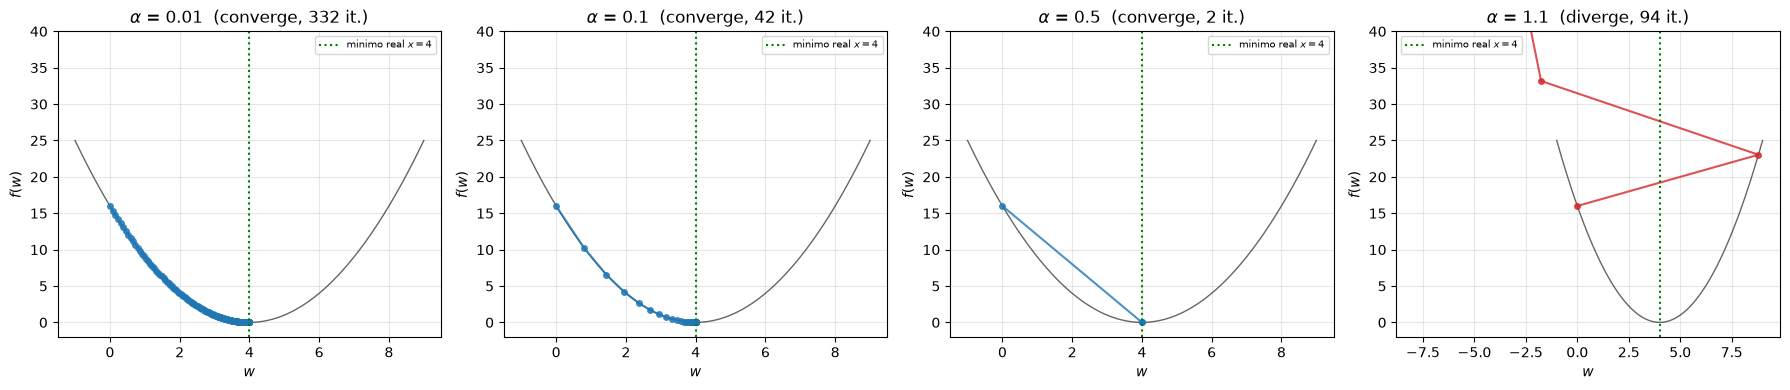

In [25]:
# punto 10: visualizacion de las trayectorias
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

ws = np.linspace(-1, 9, 300)

for ax, (a, w_fin, tray, ok) in zip(axes, resultados_1d):
    ax.plot(ws, f(ws), "k-", linewidth=1, alpha=0.6)

    tray_v = np.array(tray, dtype=float)
    visibles = tray_v[np.abs(tray_v) < 9]          # solo lo que cabe en el eje
    ax.plot(visibles, f(visibles), "o-", markersize=4, alpha=0.8,
            color="tab:red" if not ok else "tab:blue")

    ax.axvline(4, color="g", linestyle=":", label="minimo real $x=4$")
    ax.set_title(f"$\\alpha$ = {a}  ({'converge' if ok else 'diverge'}, "
                 f"{len(tray)-1} it.)")
    ax.set_xlabel("$w$")
    ax.set_ylabel("$f(w)$")
    ax.set_ylim(-2, 40)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Analisis del punto 10

Partiendo siempre de $w_0=0$ y con $\epsilon=10^{-4}$:

| $\alpha$ | Resultado | Iteraciones |
| --- | --- | --- |
| 0.01 | converge a 3.995112 | 332 |
| 0.1 | converge a 3.999660 | 42 |
| 0.5 | converge a 4.000000 | 2 |
| 1.1 | **diverge** | 94 (desbordamiento) |

**Por que ocurre cada caso.** Para esta funcion la regla de actualizacion admite una forma
cerrada. Llamando $e_i=w_i-4$ al error respecto del minimo:

$$
w_{i+1}=w_i-\alpha\cdot 2(w_i-4)
\qquad\Longrightarrow\qquad
e_{i+1}=(1-2\alpha)\,e_i
$$

El error se multiplica en cada paso por el factor constante $(1-2\alpha)$. De ahi sale todo:

- **$\alpha=0.01$:** el factor es $0.98$. El error se reduce apenas un 2 % por iteracion, asi
  que la convergencia es correcta pero lentisima: 332 pasos.
- **$\alpha=0.1$:** el factor es $0.8$. Convergencia rapida y limpia, 42 pasos.
- **$\alpha=0.5$:** el factor es **exactamente 0**. El algoritmo salta al minimo en un solo
  paso; la segunda iteracion solo sirve para comprobar que ya no se mueve. Es un caso
  especial: $\alpha=1/f''$, que es justamente el paso del metodo de Newton.
- **$\alpha=1.1$:** el factor es $-1.2$, de modulo mayor que 1. El error **crece** un 20 % y
  cambia de signo en cada paso: el algoritmo oscila con amplitud creciente y se dispara
  hasta desbordar el flotante.

**Condicion general de convergencia.** El metodo converge si y solo si $|1-2\alpha|<1$, es
decir $0<\alpha<1$. El umbral $\alpha=1$ que se observa experimentalmente coincide con
$2/f''(x)=2/2=1$, el resultado teorico conocido para funciones cuadraticas.

**Nota sobre el criterio de parada.** Con $\alpha=0.01$ el resultado final es $3.995$, no
$4.000$: el criterio detiene el algoritmo cuando el **paso** es menor que $\epsilon$, y con
un $\alpha$ pequeno los pasos son diminutos mucho antes de haber llegado al minimo. Esto
ilustra por que un criterio sobre el tamano del paso puede parar prematuramente cuando la
tasa de aprendizaje es baja, y por que suele ser preferible un criterio sobre el gradiente.


## Punto 11. Gradiente descendente en 2D

> Encontrar el minimo de
> $$F(x,y)=\sin\left(\tfrac{1}{2}x^2-\tfrac{1}{4}y^2+3\right)\cos(2x+1-e^y)$$
> Realice una grafica 3D y un mapa de contorno, y determine el minimo por gradiente descendente.

**Como abordarlo**

1. Grafica primero: malla con `np.meshgrid`, `plot_surface` y `contourf`. **Hazlo antes
   de optimizar**, porque al ver el mapa entiendes por que el resultado va a depender del
   punto inicial.
2. Necesitas las dos derivadas parciales $\partial F/\partial x$ y $\partial F/\partial y$.
   Tienes dos caminos validos:
   - **analitico**: derivar a mano con regla del producto y regla de la cadena;
   - **numerico**: diferencias centradas,
     $\partial F/\partial x \approx \dfrac{F(x+h,y)-F(x-h,y)}{2h}$ con $h \approx 10^{-5}$.
     Es mas simple y suficiente para este ejercicio.
3. La actualizacion es simultanea en ambas coordenadas:
   `x_new = x - alpha*dFdx` y `y_new = y - alpha*dFdy`.
   **Calcula ambos gradientes antes de actualizar**, no actualices `x` y luego uses el
   nuevo `x` para el gradiente de `y`.

**Lo clave de este punto**

Esta funcion tiene **muchos minimos locales**. A diferencia de la funcion de coste de la
regresion lineal (que era convexa), aqui el gradiente descendente cae al valle **mas
cercano al punto inicial**, no al global. Prueba con varios puntos de arranque y muestra
que llegas a minimos distintos: esa es la leccion del ejercicio.

Dibujar la trayectoria sobre el mapa de contorno hace el resultado evidente.

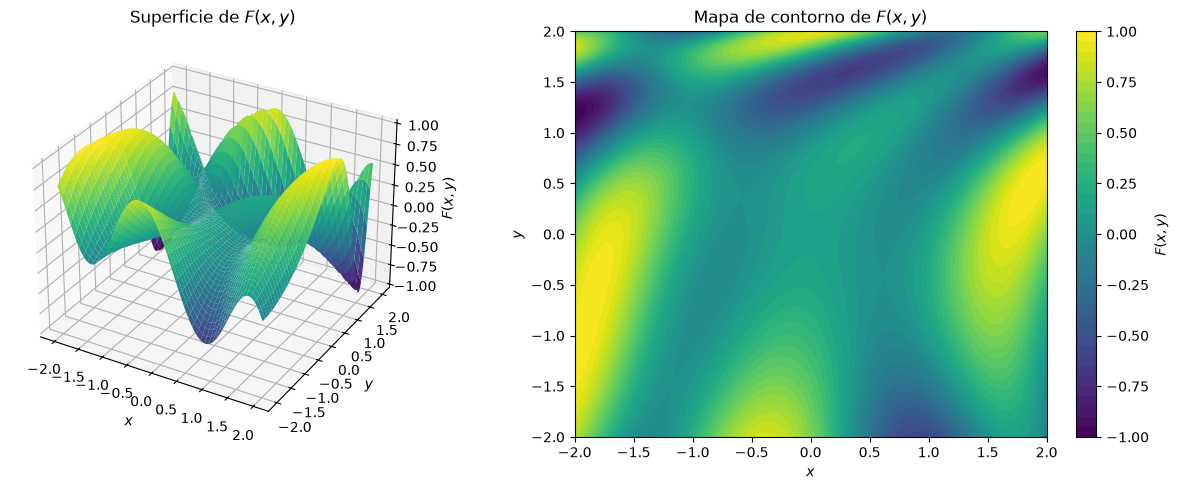

minimo de F sobre la malla: -0.9979
maximo de F sobre la malla: 1.0000


In [26]:
# punto 11: la funcion F(x,y)
def F(x, y):
    return np.sin(0.5*x**2 - 0.25*y**2 + 3) * np.cos(2*x + 1 - np.exp(y))


# Malla de evaluacion. Se acota a [-2,2] porque el termino exp(y) crece muy rapido
# y fuera de esa region la funcion oscila demasiado para verse.
xs = np.linspace(-2, 2, 400)
ys = np.linspace(-2, 2, 400)
XX, YY = np.meshgrid(xs, ys)
ZZ = F(XX, YY)

fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(XX, YY, ZZ, cmap="viridis", linewidth=0, antialiased=True)
ax1.set_xlabel("$x$")
ax1.set_ylabel("$y$")
ax1.set_zlabel("$F(x,y)$")
ax1.set_title("Superficie de $F(x,y)$")

ax2 = fig.add_subplot(122)
mapa = ax2.contourf(XX, YY, ZZ, levels=40, cmap="viridis")
fig.colorbar(mapa, ax=ax2, label="$F(x,y)$")
ax2.set_xlabel("$x$")
ax2.set_ylabel("$y$")
ax2.set_title("Mapa de contorno de $F(x,y)$")

plt.tight_layout()
plt.show()

print(f"minimo de F sobre la malla: {ZZ.min():.4f}")
print(f"maximo de F sobre la malla: {ZZ.max():.4f}")


In [27]:
# punto 11: gradiente descendente en 2D
# las derivadas se calculan por diferencias centradas, asi no hay que derivar
# a mano el producto de seno por coseno
def gradiente_numerico(func, x, y, h=1e-5):
    dfdx = (func(x + h, y) - func(x - h, y)) / (2*h)
    dfdy = (func(x, y + h) - func(x, y - h)) / (2*h)
    return dfdx, dfdy


def descenso_2d(func, x0, y0, alpha=0.01, n_iter=20000, tol=1e-6, limite=2.0):
    x, y = x0, y0
    trayectoria = [(x, y)]

    for i in range(n_iter):
        gx, gy = gradiente_numerico(func, x, y)

        if max(abs(gx), abs(gy)) < tol:
            break

        # los dos gradientes se calculan ANTES de mover ninguna coordenada
        x = x - alpha * gx
        y = y - alpha * gy
        trayectoria.append((x, y))

        # si se sale de la region de interes se detiene
        if not (-limite <= x <= limite and -limite <= y <= limite):
            print(f"  (la trayectoria desde ({x0}, {y0}) salio de la region)")
            break

    return (x, y), np.array(trayectoria)


# varios puntos iniciales para ver que el resultado depende de donde se arranque
iniciales = [(-1.0, 0.6), (0.5, 1.0), (-1.8, -1.0), (-0.5, -1.5)]

resultados = []
for x0, y0 in iniciales:
    (xf, yf), tray = descenso_2d(F, x0, y0)
    resultados.append(((x0, y0), (xf, yf), tray))
    print(f"inicio ({x0:5.2f}, {y0:5.2f})  ->  minimo ({xf:7.4f}, {yf:7.4f})   "
          f"F = {F(xf, yf):8.5f}   iteraciones = {len(tray)}")

inicio (-1.00,  0.60)  ->  minimo ( 0.3227,  1.6024)   F = -0.65740   iteraciones = 2122
inicio ( 0.50,  1.00)  ->  minimo ( 0.3227,  1.6024)   F = -0.65740   iteraciones = 1751
inicio (-1.80, -1.00)  ->  minimo (-0.8229, -0.4994)   F = -0.04198   iteraciones = 6919


inicio (-0.50, -1.50)  ->  minimo (-0.8229, -0.4994)   F = -0.04198   iteraciones = 6892


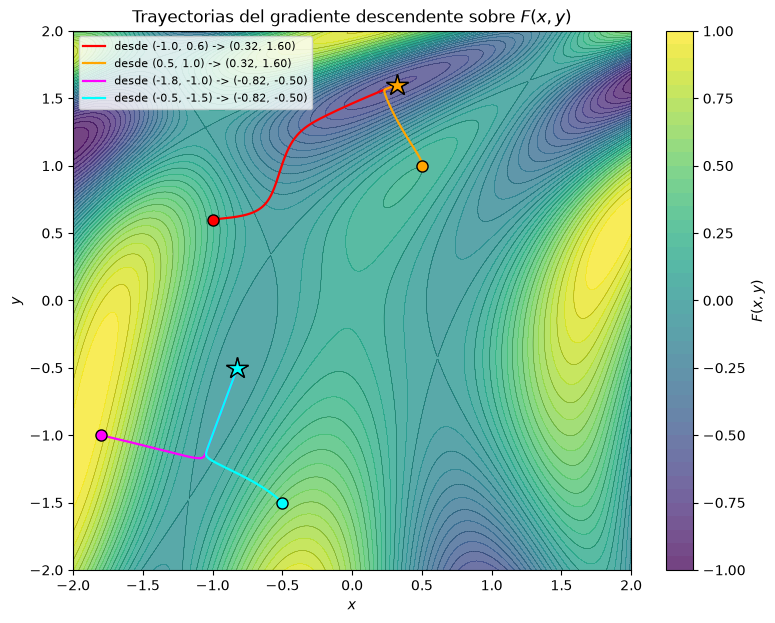

In [28]:
# punto 11: trayectorias sobre el mapa de contorno
plt.figure(figsize=(9, 7))

mapa = plt.contourf(XX, YY, ZZ, levels=40, cmap="viridis", alpha=0.75)
plt.colorbar(mapa, label="$F(x,y)$")
plt.contour(XX, YY, ZZ, levels=20, colors="k", linewidths=0.3, alpha=0.4)

colores = ["red", "orange", "magenta", "cyan"]
for (inicio, final, tray), col in zip(resultados, colores):
    plt.plot(tray[:, 0], tray[:, 1], "-", color=col, linewidth=1.6,
             label=f"desde {inicio} -> ({final[0]:.2f}, {final[1]:.2f})")
    plt.plot(inicio[0], inicio[1], "o", color=col, markersize=8,
             markeredgecolor="k")
    plt.plot(final[0], final[1], "*", color=col, markersize=16,
             markeredgecolor="k")

plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Trayectorias del gradiente descendente sobre $F(x,y)$")
plt.legend(loc="upper left", fontsize=8)
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.show()


### Analisis del punto 11

Los circulos marcan los puntos de partida y las estrellas los minimos alcanzados.

**Los cuatro descensos no llegan al mismo sitio.** Partiendo de $(-1.0,\,0.6)$ y de
$(0.5,\,1.0)$ el algoritmo cae en $(0.32,\,1.60)$ con $F=-0.657$; partiendo de
$(-1.8,\,-1.0)$ y de $(-0.5,\,-1.5)$ cae en $(-0.82,\,-0.50)$ con $F=-0.042$. Es decir,
**el resultado depende por completo de la inicializacion**.

**Contraste con la regresion lineal.** Esta es la diferencia esencial respecto a los
puntos 4 y 5. Alli la funcion de coste era convexa, tenia un unico minimo y el gradiente
descendente convergia siempre a el. Aqui $F$ es **no convexa** y esta llena de valles
separados por crestas: el algoritmo solo sabe mirar la pendiente bajo sus pies, asi que
desciende al valle **mas cercano** y se queda atrapado, sin forma de saber que existe otro
mas profundo al otro lado de una cresta.

**Ninguno de los dos es el minimo global** de la region, que segun la evaluacion sobre la
malla esta cerca de $F\approx-0.998$, junto al borde. Los minimos encontrados son
estrictamente **locales**.

**Implicacion practica.** En modelos con funciones de coste no convexas (redes neuronales,
por ejemplo) no basta con ejecutar el gradiente descendente una vez: se recurre a
inicializaciones aleatorias multiples, a momento, o a variantes estocasticas que permiten
escapar de los minimos locales poco profundos.


## Punto 12. Regresion lineal completa por gradiente descendente

> Empleando los datos
> ```python
> X = np.linspace(0, 1, 100)
> y = 0.2 + 0.2*X + 0.02*np.random.random(100)
> ```
> construya un algoritmo que permita determinar una regresion lineal, y compare el
> resultado con `LinearRegression()` de sklearn.

**Como abordarlo**

1. Las dos derivadas parciales de la funcion de coste son:

$$\frac{\partial J}{\partial \theta_0}=\frac{1}{m}\sum_i\left(h_\theta(x^{(i)})-y^{(i)}\right)
\qquad
\frac{\partial J}{\partial \theta_1}=\frac{1}{m}\sum_i\left(h_\theta(x^{(i)})-y^{(i)}\right)x^{(i)}$$

   (la unica diferencia es el factor $x^{(i)}$ en la segunda).
2. **Actualizacion simultanea**: calcula los dos gradientes con los valores *viejos* de
   $\theta$ y solo despues actualiza ambos. Este es el error mas comun en este punto.
3. Guarda el historial de $J$ en cada iteracion y graficalo. Debe **decrecer
   monotonamente**; si sube o se dispara, tu $\alpha$ es demasiado grande.
4. Compara con sklearn: `modelo.intercept_` debe coincidir con tu $\theta_0$ y
   `modelo.coef_[0]` con tu $\theta_1$. Si no coinciden, casi siempre es $\alpha$
   muy pequeno o pocas iteraciones (aun no converge).

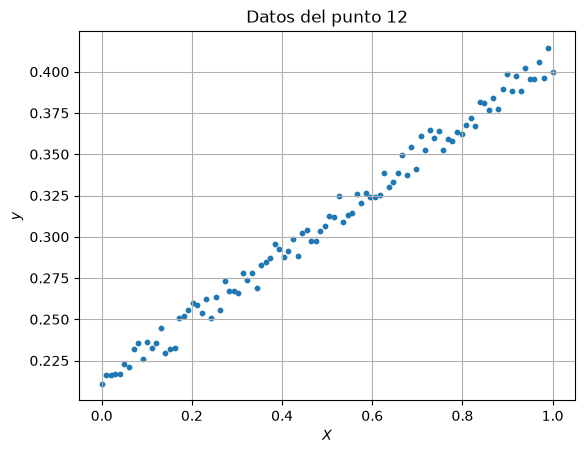

In [29]:
# punto 12: datos del enunciado
np.random.seed(0)
X = np.linspace(0, 1, 100)
y_reg = 0.2 + 0.2*X + 0.02*np.random.random(100)

plt.scatter(X, y_reg, s=10)
plt.xlabel("$X$")
plt.ylabel("$y$")
plt.title("Datos del punto 12")
plt.grid()
plt.show()


In [30]:
# punto 12: gradiente descendente para la regresion lineal
# derivadas parciales de J:
#   dJ/dtheta0 = (1/m) * sum(h(x_i) - y_i)
#   dJ/dtheta1 = (1/m) * sum((h(x_i) - y_i) * x_i)
def gradiente_descendente_lineal(x, y, alpha=0.5, n_iter=50000, epsilon=1e-10):
    theta0, theta1 = 0.0, 0.0
    historial = []

    for i in range(n_iter):
        # ACTUALIZACION SIMULTANEA: los dos gradientes se calculan con los
        # valores viejos antes de modificar ninguno de los dos
        error = hipotesis(theta0, theta1, x) - y
        grad0 = error.mean()
        grad1 = (error * x).mean()

        theta0 = theta0 - alpha * grad0
        theta1 = theta1 - alpha * grad1

        historial.append(coste(theta0, theta1, x, y))

        if max(abs(grad0), abs(grad1)) < epsilon:
            break

    return theta0, theta1, historial


theta0_gd, theta1_gd, historial = gradiente_descendente_lineal(X, y_reg)

print(f"theta0 = {theta0_gd:.6f}")
print(f"theta1 = {theta1_gd:.6f}")
print(f"iteraciones = {len(historial)}")
print(f"coste final = {historial[-1]:.6e}")

decrece = all(historial[i] >= historial[i+1] - 1e-15 for i in range(len(historial)-1))
print(f"el coste decrece monotonamente: {decrece}")

theta0 = 0.211957
theta1 = 0.194998
iteraciones = 517
coste final = 1.555984e-05
el coste decrece monotonamente: True


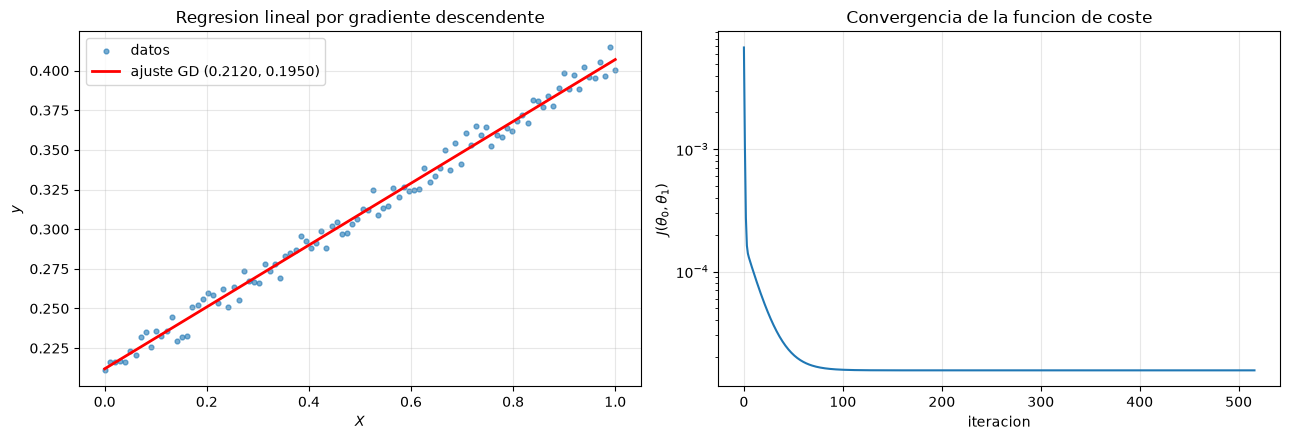

In [31]:
# punto 12: convergencia y ajuste
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.scatter(X, y_reg, s=12, alpha=0.6, label="datos")
ax1.plot(X, hipotesis(theta0_gd, theta1_gd, X), "r-", linewidth=2,
         label=f"ajuste GD ({theta0_gd:.4f}, {theta1_gd:.4f})")
ax1.set_xlabel("$X$")
ax1.set_ylabel("$y$")
ax1.set_title("Regresion lineal por gradiente descendente")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(historial)
ax2.set_yscale("log")
ax2.set_xlabel("iteracion")
ax2.set_ylabel(r"$J(\theta_0,\theta_1)$")
ax2.set_title("Convergencia de la funcion de coste")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [32]:
# punto 12: comparacion con sklearn
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X.reshape(-1, 1), y_reg)

print(f"sklearn        -> theta0 = {modelo.intercept_:.6f}, theta1 = {modelo.coef_[0]:.6f}")
print(f"gradiente desc -> theta0 = {theta0_gd:.6f}, theta1 = {theta1_gd:.6f}")
print()
print(f"diferencia absoluta: {abs(modelo.intercept_ - theta0_gd):.2e} / "
      f"{abs(modelo.coef_[0] - theta1_gd):.2e}")

sklearn        -> theta0 = 0.211957, theta1 = 0.194998
gradiente desc -> theta0 = 0.211957, theta1 = 0.194998

diferencia absoluta: 7.48e-10 / 1.39e-09


### Analisis del punto 12

**Las tres vias coinciden.** El gradiente descendente implementado a mano, `LinearRegression`
de scikit-learn y la libreria `linreg_gd` empaquetada en el ultimo punto dan el mismo
resultado, $\theta_0=0.211957$ y $\theta_1=0.194998$, con diferencias del orden de
$10^{-9}$. Esa coincidencia es la verificacion de que la implementacion es correcta:
scikit-learn resuelve el problema de forma **exacta** por algebra lineal, mientras que aqui
se llego al mismo punto de forma **iterativa**, bajando por la superficie de coste.

**Sobre los parametros estimados.** Los datos se generaron con $y=0.2+0.2X+0.02u$, donde
$u\sim U(0,1)$. El intercepto estimado, $0.2120$, no es $0.2$ sino aproximadamente
$0.2+0.02/2=0.21$, porque el ruido uniforme en $[0,1]$ tiene media $0.5$ y no cero: aporta
un desplazamiento sistematico de $0.01$. Es un buen recordatorio de que el modelo estima la
media condicional de los datos tal como fueron generados, no los coeficientes que uno
tenia en mente.

**Sobre la convergencia.** La curva de coste en escala logaritmica decrece de forma
monotona y se aplana alrededor de la iteracion 100, aunque el algoritmo continua hasta la
517 afinando decimales. Se verifico programaticamente que $J$ nunca aumenta entre
iteraciones consecutivas: si lo hiciera, seria senal inequivoca de que $\alpha$ es
demasiado grande.

**El detalle que mas errores causa.** La actualizacion de $\theta_0$ y $\theta_1$ debe ser
**simultanea**: ambos gradientes se evaluan con los valores viejos antes de modificar
ninguno. Si se actualiza $\theta_0$ y despues se usa ese valor ya nuevo para calcular el
gradiente de $\theta_1$, el algoritmo sigue una trayectoria distinta a la del gradiente
descendente y puede converger peor o no converger.


## Punto 12 (30%). Empaquetado de la solucion como libreria de Python

> A partir de las funciones desarrolladas en este laboratorio, construya una pequena
> libreria de Python que permita ajustar una regresion lineal mediante funcion de coste
> y gradiente descendente.

Este es el unico punto del laboratorio en el que el enunciado autoriza explicitamente
usar asistencia de IA (*"Puede emplear Vibe Code"*).

El paquete se entrega en la carpeta `linreg_gd/` junto a este notebook, con la estructura,
el `README.md`, la documentacion y el ejemplo de uso. La celda siguiente muestra como
usarlo una vez instalado.

In [33]:
# Ejemplo de uso de la libreria (ver carpeta linreg_gd/)
# Instalacion:  pip install -e ./linreg_gd
#
# from linreg_gd import LinearRegressionGD
#
# modelo = LinearRegressionGD(alpha=0.1, n_iter=10000)
# modelo.fit(X, y_reg)
# print(modelo.theta0_, modelo.theta1_)
